<a href="https://colab.research.google.com/github/magnogomes874/SSD-/blob/main/MPV%201%20-SSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MVP – Classificação do Risco de Ruptura e Nível Crítico de Estoque


Disciplina: Sistemas de Suporte à Decisão


Universidade de Brasília (UnB)

Aluno: Magno Gomes Sousa
--------------------------------------------------------------------------------
Definição do Problema
Este MVP é para almoxarifados e centros de distribuição. Em vez de depender de fórmulas matemáticas complexas, o sistema atua como uma ferramenta de triagem automática que classifica os itens do estoque em 3 ações práticas imediatas:

0 - Comprar Urgente: Item em nível de risco iminente de falta.

1 - Nível Operacional Normal: Estoque saudável; nenhuma ação necessária no momento.

2 - Pausar Compras / Excesso: Produto com giro lento ou excesso de caixas no galpão.

#**Hipótese**

Informações cadastrais e logísticas simples do dia a dia (Categoria, Fornecedor, Espaço Ocupado/Volume, Velocidade de Saída, Dias sem Movimento e Dias de Espera do Fornecedor) contêm padrões suficientes para prever qual ação o comprador/estoquista deve tomar, padronizando a rotina do time.

1. Configuração do Ambiente.

In [14]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("-> Ambiente operacional configurado com sucesso!")

-> Ambiente operacional configurado com sucesso!


# 2. Carga e Preparação da Base Operacional

Base contendo o histórico de 2.500 itens cadastrados e seu comportamento no armazém:

In [15]:
np.random.seed(42)
n = 2500

categorias = ['Bebidas', 'Alimentos', 'Embalagens', 'Limpeza', 'Descartáveis', 'Higiene']
fornecedores = ['Distribuidor Local', 'Direto de Fábrica', 'Importador', 'Atacadista']
velocidade_giro = ['Alto Giro (Sai Todo Dia)', 'Giro Médio (Semanal)', 'Baixo Giro (Lento)']
espaco_armazem = ['Pequeno (Prateleira)', 'Médio (Caixa)', 'Grande (Palete Fechado)']

df = pd.DataFrame({
    'codigo_item': [f'ITEM-{2000+i}' for i in range(n)],
    'categoria': np.random.choice(categorias, n, p=[0.30, 0.25, 0.15, 0.10, 0.10, 0.10]),
    'tipo_fornecedor': np.random.choice(fornecedores, n, p=[0.40, 0.30, 0.20, 0.10]),
    'velocidade_giro': np.random.choice(velocidade_giro, n, p=[0.40, 0.40, 0.20]),
    'espaco_armazem': np.random.choice(espaco_armazem, n, p=[0.40, 0.40, 0.20]),
    'dias_espera_entrega': np.random.choice([2, 5, 10, 15, 30], n, p=[0.30, 0.35, 0.20, 0.10, 0.05]),
    'dias_sem_nenhuma_saida': np.random.randint(0, 60, size=n),
    'unidades_recorrentes_semana': np.random.randint(5, 300, size=n)
})

print(f"Base de estoque pronta com {df.shape[0]:,} itens.")
df.head()

Base de estoque pronta com 2,500 itens.


,codigo_item,categoria,tipo_fornecedor,velocidade_giro,espaco_armazem,dias_espera_entrega,dias_sem_nenhuma_saida,unidades_recorrentes_semana
0,ITEM-2000,Alimentos,Importador,Alto Giro (Sai Todo Dia),Médio (Caixa),5,42,258
1,ITEM-2001,Higiene,Importador,Giro Médio (Semanal),Grande (Palete Fechado),5,38,35
2,ITEM-2002,Limpeza,Direto de Fábrica,Baixo Giro (Lento),Pequeno (Prateleira),2,11,165
3,ITEM-2003,Embalagens,Atacadista,Alto Giro (Sai Todo Dia),Pequeno (Prateleira),5,47,219
4,ITEM-2004,Bebidas,Distribuidor Local,Baixo Giro (Lento),Médio (Caixa),5,4,173


**3. Definição da Ação Recomendada**

A regra operacional de negócio do almoxarifado define a prioridade de atendimento:

0 - Comprar Urgente: Produtos de Alto Giro que demoram para ser entregues ($\ge 10$ dias) ou itens com saída rápida e poucos dias parados.

2 - Pausar Compras / Excesso: Produtos parados há mais de 25 dias ou itens de Baixo Giro ocupando espaço de palete.

1 - Nível Normal: Demais casos de rotina padrão.

In [16]:
def definir_acao_operacional(row):
    if row['dias_sem_nenhuma_saida'] > 25 or (row['velocidade_giro'] == 'Baixo Giro (Lento)' and row['espaco_armazem'] == 'Grande (Palete Fechado)'):
        return 2 # Pausar Compras / Excesso
    elif (row['velocidade_giro'] == 'Alto Giro (Sai Todo Dia)' and row['dias_espera_entrega'] >= 10) or (row['dias_sem_nenhuma_saida'] <= 2 and row['unidades_recorrentes_semana'] > 150):
        return 0 # Comprar Urgente
    else:
        return 1 # Normal

df['acao_operacional'] = df.apply(definir_acao_operacional, axis=1)

# Distribuição das ações na rotina
print("=== DISTRIBUIÇÃO DAS RECOMENDAÇÕES NO ALMOXARIFADO ===")
dist = df['acao_operacional'].value_counts(normalize=True).rename(
    index={0: '0 - Comprar Urgente', 1: '1 - Nível Normal', 2: '2 - Pausar / Excesso'}
)
print(dist.apply(lambda x: f"{x*100:.1f}%"))

=== DISTRIBUIÇÃO DAS RECOMENDAÇÕES NO ALMOXARIFADO ===
acao_operacional
2 - Pausar / Excesso    58.6%
1 - Nível Normal        33.1%
0 - Comprar Urgente      8.2%
Name: proportion, dtype: object


# **4. Visualização Prática do Armazém**

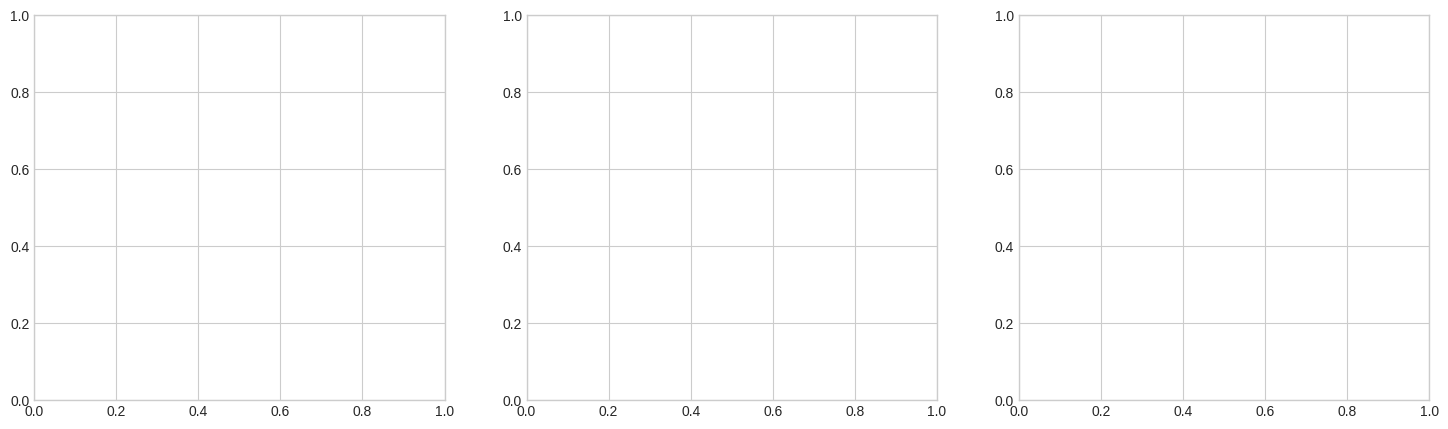

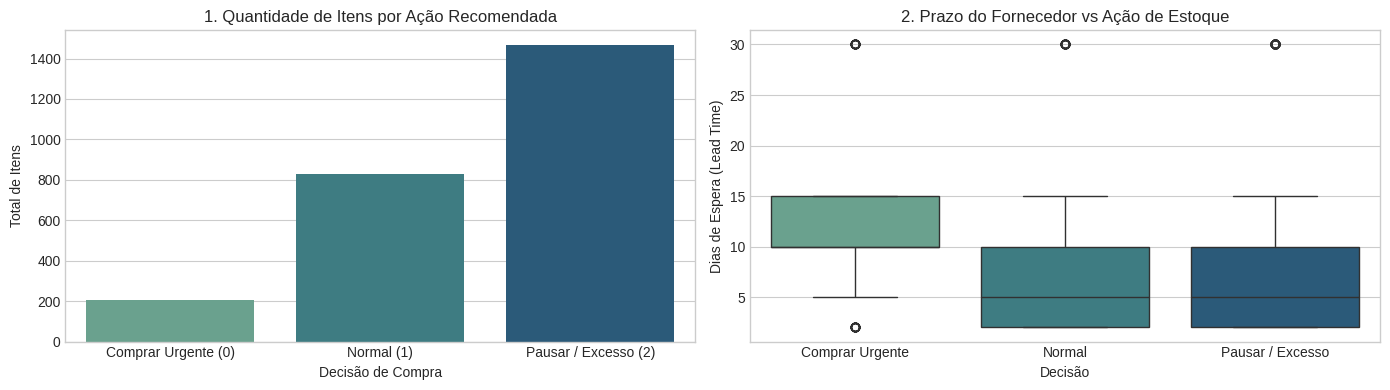

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Contagem das Ações
sns.countplot(data=df, x='acao_operacional', ax=axes[0], palette='crest')
axes[0].set_title('1. Quantidade de Itens por Ação Recomendada')
axes[0].set_xticklabels(['Comprar Urgente (0)', 'Normal (1)', 'Pausar / Excesso (2)'])
axes[0].set_xlabel('Decisão de Compra')
axes[0].set_ylabel('Total de Itens')

# 2. Ação vs Dias de Espera do Fornecedor
sns.boxplot(data=df, x='acao_operacional', y='dias_espera_entrega', ax=axes[1], palette='crest')
axes[1].set_title('2. Prazo do Fornecedor vs Ação de Estoque')
axes[1].set_xticklabels(['Comprar Urgente', 'Normal', 'Pausar / Excesso'])
axes[1].set_xlabel('Decisão')
axes[1].set_ylabel('Dias de Espera (Lead Time)')

plt.tight_layout()
plt.show()

**5. Preparação dos Dados para Treinamento**

In [18]:
features_num = ['dias_espera_entrega', 'dias_sem_nenhuma_saida', 'unidades_recorrentes_semana']
features_cat = ['categoria', 'tipo_fornecedor', 'velocidade_giro', 'espaco_armazem']
target = 'acao_operacional'

X = df[features_num + features_cat]
y = df[target]

# Divisão simples 80% Treino e 20% Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ]
)
print("Pipeline pronto: variáveis preparadas para os modelos.")

Pipeline pronto: variáveis preparadas para os modelos.


**6. Treinamento e Comparação dos Modelos**

Comparação entre um baseline ingênuo, um modelo linear simples e uma árvore de decisão:

In [19]:
modelos = {
    "Baseline (Chute Frequente)": DummyClassifier(strategy='most_frequent'),
    "Regressão Logística": LogisticRegression(max_iter=500),
    "Random Forest (Árvores de Decisão)": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

resultados = {}

for nome, modelo in modelos.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    resultados[nome] = {
        "Acurácia Geral": f"{pipe.score(X_test, y_test)*100:.2f}%",
        "F1-Score Macro": f"{f1_score(y_test, preds, average='macro'):.4f}"
    }

pd.DataFrame(resultados).T

,Acurácia Geral,F1-Score Macro
Baseline (Chute Frequente),58.60%,0.2463
Regressão Logística,90.60%,0.8066
Random Forest (Árvores de Decisão),97.20%,0.9179


**7. Avaliação Operacional (Matriz de Confusão)**

=== RELATÓRIO OPERACIONAL DE ACERTOS ===
                 precision    recall  f1-score   support

Comprar Urgente       1.00      0.66      0.79        41
         Normal       0.92      1.00      0.96       166
 Pausar Compras       1.00      1.00      1.00       293

       accuracy                           0.97       500
      macro avg       0.97      0.89      0.92       500
   weighted avg       0.97      0.97      0.97       500



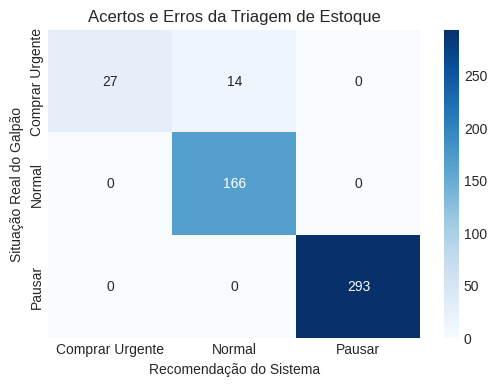

In [20]:
modelo_final = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
])
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

print("=== RELATÓRIO OPERACIONAL DE ACERTOS ===")
print(classification_report(y_test, y_pred, target_names=['Comprar Urgente', 'Normal', 'Pausar Compras']))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Comprar Urgente', 'Normal', 'Pausar'],
            yticklabels=['Comprar Urgente', 'Normal', 'Pausar'])
plt.title('Acertos e Erros da Triagem de Estoque')
plt.xlabel('Recomendação do Sistema')
plt.ylabel('Situação Real do Galpão')
plt.show()

**8. Importância dos Fatores para o Estoquista**

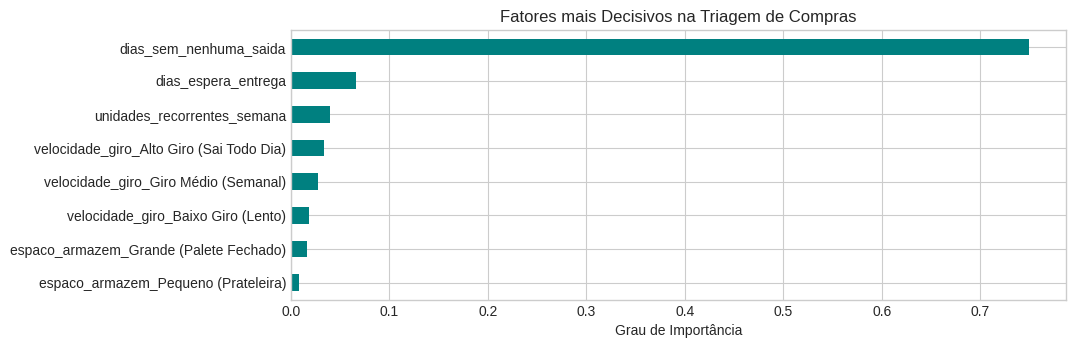

In [21]:
rf = modelo_final.named_steps['clf']
encoder = modelo_final.named_steps['prep'].named_transformers_['cat']
colunas = features_num + list(encoder.get_feature_names_out(features_cat))

importancias = pd.Series(rf.feature_importances_, index=colunas).sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 3.5))
importancias.plot(kind='barh', color='teal').invert_yaxis()
plt.title('Fatores mais Decisivos na Triagem de Compras')
plt.xlabel('Grau de Importância')
plt.show()

9. Teste Prático (Simulador de Decisão de Balcão)

Exemplo prático de como consultar um item no dia a dia para saber o que fazer:

In [22]:
novo_item = pd.DataFrame([{
    'categoria': 'Bebidas',
    'tipo_fornecedor': 'Direto de Fábrica',
    'velocidade_giro': 'Alto Giro (Sai Todo Dia)',
    'espaco_armazem': 'Médio (Caixa)',
    'dias_espera_entrega': 15,
    'dias_sem_nenhuma_saida': 1,
    'unidades_recorrentes_semana': 220
}])

predicao = modelo_final.predict(novo_item)[0]
rotulos = {
    0: "🚨 COMPRAR URGENTE (Item com alto giro e fornecedor demorado)",
    1: "✔️ ESTOQUE NORMAL (Sem necessidade de reposição imediata)",
    2: "⏸️ PAUSAR COMPRAS (Item parado ou ocupando muito espaço)"
}

print("=" * 65)
print("             RECOMENDAÇÃO DO SISTEMA DE SUPORTE À DECISÃO")
print("=" * 65)
print(f"Resultado para o item consultado: \n-> {rotulos[predicao]}")

             RECOMENDAÇÃO DO SISTEMA DE SUPORTE À DECISÃO
Resultado para o item consultado: 
-> 🚨 COMPRAR URGENTE (Item com alto giro e fornecedor demorado)


**10. Conclusão**


**Praticidade no Chão de Fábrica:** Elimina planilhas complexas e substitui cálculos de ponto de pedido por uma lista direta de itens prioritários.

**Prevenção de Rupturas:** O modelo prioriza itens com prazo longo de fornecedor e saída rápida, acionando o comprador antes da falta.

**Liberação de Espaço e Capital:** Identifica produtos de baixo giro ocupando paletes, evitando novos pedidos desnecessários.